# Credit Card Default Risk Prediction

## Goal

Build a machine learning model that predicts whether a credit card client is likely to default next month.

The project will use:
- data cleaning
- exploratory data analysis
- feature engineering
- logistic regression
- random forest
- model evaluation
- risk band creation

## Install packages

In [ ]:
%%capture

%pip install -r ../requirements.txt

## Import basic libraries

In [ ]:
import json
from pathlib import Path

import joblib # save trained models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Set up project paths

In [ ]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

for folder in [RAW_DIR, PROCESSED_DIR, MODELS_DIR, REPORTS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True) # create the folder if it does not exist

RAW_DATA_PATH = RAW_DIR / "credit_card_default_uci.csv"
PROCESSED_DATA_PATH = PROCESSED_DIR / "credit_card_default_features.csv"
MODEL_PATH = MODELS_DIR / "best_credit_default_model.joblib"
METRICS_PATH = REPORTS_DIR / "model_metrics.json"

## Download dataset

In [ ]:
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=350) # `Default of Credit Card Clients` dataset on UCI ML Repo

X = dataset.data.features.copy() # input columns
y = dataset.data.targets.copy() # output column

df_raw = pd.concat([X, y], axis=1) # combine the input and output columns into a single dataframe for analysis

df_raw.to_csv(RAW_DATA_PATH, index=False) # save raw data into data/raw folder, does not change original dataset

df_raw.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## Inspect raw data

In [ ]:
print("Shape:", df_raw.shape) # print the shape of the dataframe (rows, columns)
print("\nColumns:")
print(df_raw.columns.tolist()) # print the list of column names in the dataframe

df_raw.info() # print the summary of the dataframe, including data types and non-null counts

Shape: (30000, 24)

Columns:
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'Y']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18 

## Rename columns

In [ ]:
rename_map = {
    "ID": "ID", # Unique identifier for each client
    "X1": "LIMIT_BAL", # Amount of the given credit (NT dollar)
    "X2": "SEX", # Gender (1 = male; 2 = female)
    "X3": "EDUCATION", # Education (1 = graduate school; 2 = university; 3 = high school; 4 = others)
    "X4": "MARRIAGE", # Marital status (1 = married; 2 = single; 3 = others)
    "X5": "AGE", # Age (in years)
    "X6": "PAY_0", # Payment status of the previous month (-1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above)
    "X7": "PAY_2", # Payment status of the second previous month
    "X8": "PAY_3", # Payment status of the third previous month
    "X9": "PAY_4", # Payment status of the fourth previous month
    "X10": "PAY_5", # Payment status of the fifth previous month
    "X11": "PAY_6", # Payment status of the sixth previous month
    "X12": "BILL_AMT1", # Bill amount of the first previous month
    "X13": "BILL_AMT2", # Bill amount of the second previous month
    "X14": "BILL_AMT3", # Bill amount of the third previous month
    "X15": "BILL_AMT4", # Bill amount of the fourth previous month
    "X16": "BILL_AMT5", # Bill amount of the fifth previous month
    "X17": "BILL_AMT6", # Bill amount of the sixth previous month
    "X18": "PAY_AMT1", # Payment amount of the first previous month
    "X19": "PAY_AMT2", # Payment amount of the second previous month
    "X20": "PAY_AMT3", # Payment amount of the third previous month
    "X21": "PAY_AMT4", # Payment amount of the fourth previous month
    "X22": "PAY_AMT5", # Payment amount of the fifth previous month
    "X23": "PAY_AMT6", # Payment amount of the sixth previous month
    "Y": "default_next_month", # Target variable: 1 if the client defaults on payment next month, 0 otherwise
    "default payment next month": "default_next_month", # Target variable: 1 if the client defaults on payment next month, 0 otherwise
}

df = df_raw.rename(columns={k: v for k, v in rename_map.items() if k in df_raw.columns})

df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month
47,150000,2,5,2,46,0,0,-1,0,0,...,1170,0,0,1013,1170,0,0,0,0,1
69,20000,1,5,2,22,2,0,0,0,0,...,18085,11205,5982,0,1200,1000,500,1000,0,0
385,410000,2,5,1,42,0,0,0,0,0,...,240865,234939,240176,15000,14000,9000,8500,9000,8300,0
1265,80000,2,5,2,27,0,0,0,0,0,...,48443,49478,43264,2600,1800,1700,1700,1700,1300,0
1282,140000,2,5,2,36,0,0,0,0,0,...,53055,102587,98251,4182,4000,4000,98000,4000,3500,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29610,220000,1,5,1,37,-2,-2,-1,-1,-1,...,1850,6938,5034,1966,6203,1850,6938,101,2932,0
29811,50000,1,5,2,46,0,0,0,-1,0,...,19183,19563,19157,1423,1000,19183,687,696,776,0
29839,150000,1,5,1,36,0,0,0,0,0,...,136378,139219,142172,5500,3800,3900,4000,4100,4100,0
29920,50000,1,5,1,45,2,0,0,0,0,...,50947,51020,0,3000,3428,2002,1023,0,0,1


## Check for missing values and duplicates

In [12]:
print("Missing values:")
display(df.isna().sum())

print("Duplicate rows:")
print(df.duplicated().sum())

Missing values:


LIMIT_BAL             0
SEX                   0
EDUCATION             0
MARRIAGE              0
AGE                   0
PAY_0                 0
PAY_2                 0
PAY_3                 0
PAY_4                 0
PAY_5                 0
PAY_6                 0
BILL_AMT1             0
BILL_AMT2             0
BILL_AMT3             0
BILL_AMT4             0
BILL_AMT5             0
BILL_AMT6             0
PAY_AMT1              0
PAY_AMT2              0
PAY_AMT3              0
PAY_AMT4              0
PAY_AMT5              0
PAY_AMT6              0
default_next_month    0
dtype: int64

Duplicate rows:
35


## Target Variable

The target column is:

`default_next_month`

Meaning:
- `0` = client did not default next month
- `1` = client defaulted next month

This is a binary classification problem.

## Data cleaning

In [30]:
df = df.drop_duplicates().copy()

df["EDUCATION"] = df["EDUCATION"].replace({
    0: 4,
    5: 4,
    6: 4
})

df["MARRIAGE"] = df["MARRIAGE"].replace({
    0: 3
})

df[["SEX", "EDUCATION", "MARRIAGE"]].describe()

,SEX,EDUCATION,MARRIAGE
count,29965.000000,29965.000000,29965.000000
mean,1.603738,1.842750,1.557283
std,0.489128,0.744513,0.521431
min,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000
50%,2.000000,2.000000,2.000000
75%,2.000000,2.000000,2.000000
max,2.000000,4.000000,3.000000


In [31]:
target_counts = df["default_next_month"].value_counts().sort_index()
target_percentages = df["default_next_month"].value_counts(normalize=True).sort_index()

display(target_counts)
display(target_percentages)

default_next_month
0    23335
1     6630
Name: count, dtype: int64

default_next_month
0    0.778742
1    0.221258
Name: proportion, dtype: float64

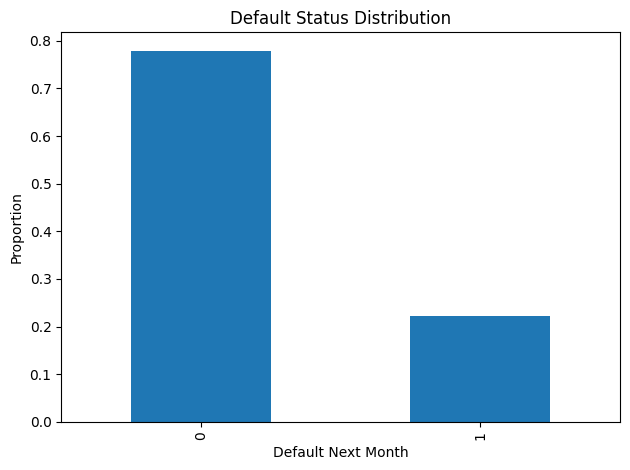

In [32]:
fig, ax = plt.subplots()

target_percentages.plot(kind="bar", ax=ax)

ax.set_title("Default Status Distribution")
ax.set_xlabel("Default Next Month")
ax.set_ylabel("Proportion")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "default_distribution.png", bbox_inches="tight")
plt.show()

## Explore recent repayment status

In [33]:
default_rate_by_pay0 = df.groupby("PAY_0")["default_next_month"].mean()

display(default_rate_by_pay0)

PAY_0
-2    0.132364
-1    0.167899
 0    0.128113
 1    0.340333
 2    0.691298
 3    0.757764
 4    0.684211
 5    0.500000
 6    0.545455
 7    0.777778
 8    0.578947
Name: default_next_month, dtype: float64

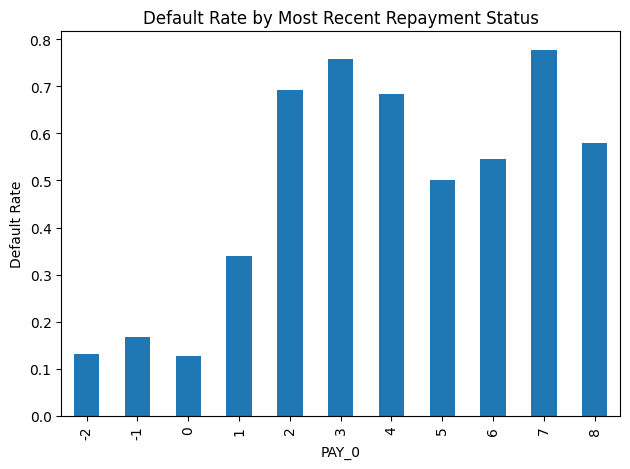

In [34]:
fig, ax = plt.subplots()

default_rate_by_pay0.plot(kind="bar", ax=ax)

ax.set_title("Default Rate by Most Recent Repayment Status")
ax.set_xlabel("PAY_0")
ax.set_ylabel("Default Rate")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "default_rate_by_pay0.png", bbox_inches="tight")
plt.show()

## Feature Engineering

The raw dataset has monthly repayment, bill, and payment columns.

We will create new risk features such as:
- number of delayed months
- maximum repayment delay
- recent delay flag
- average bill amount
- average payment amount
- payment-to-bill ratio
- credit utilization proxy

In [ ]:
df_features = df.copy()

pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

bill_cols = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

pay_amt_cols = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

df_features["delay_months_count"] = (df_features[pay_status_cols] > 0).sum(axis=1) # number of months with payment delay
df_features["max_delay"] = df_features[pay_status_cols].max(axis=1) # maximum delay in months across the last 6 months
df_features["recent_delay"] = (df_features["PAY_0"] > 0).astype(int) # 1 if there was a delay in the most recent month, 0 otherwise

df_features["avg_bill_amt"] = df_features[bill_cols].mean(axis=1) # average bill amount across the last 6 months
df_features["avg_pay_amt"] = df_features[pay_amt_cols].mean(axis=1)

df_features["payment_to_bill_ratio"] = (
    df_features["avg_pay_amt"] / df_features["avg_bill_amt"].replace(0, np.nan) # ratio of average payment amount to average bill amount
)

df_features["payment_to_bill_ratio"] = (
    df_features["payment_to_bill_ratio"] 
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

df_features["credit_utilization_proxy"] = (
    df_features["avg_bill_amt"] / df_features["LIMIT_BAL"].replace(0, np.nan) # proxy for credit utilization ratio (average bill amount divided by credit limit
)

df_features["credit_utilization_proxy"] = (
    df_features["credit_utilization_proxy"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

df_features["bill_trend"] = df_features["BILL_AMT1"] - df_features["BILL_AMT6"] # trend in bill amount over the last 6 months (positive value indicates increasing bill amount, negative value indicates decreasing bill amount)
df_features["payment_trend"] = df_features["PAY_AMT1"] - df_features["PAY_AMT6"] # trend in payment amount over the last 6 months (positive value indicates increasing payment amount, negative value indicates decreasing payment amount)

df_features.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,default_next_month,delay_months_count,max_delay,recent_delay,avg_bill_amt,avg_pay_amt,payment_to_bill_ratio,credit_utilization_proxy,bill_trend,payment_trend
0,20000,2,2,1,24,2,2,-1,-1,-2,...,1,2,2,1,1284.000000,114.833333,0.089434,0.064200,3913,0
1,120000,2,2,2,26,-1,2,0,0,0,...,1,2,2,0,2846.166667,833.333333,0.292791,0.023718,-579,-2000
2,90000,2,2,2,34,0,0,0,0,0,...,0,0,0,0,16942.166667,1836.333333,0.108388,0.188246,13690,-3482
3,50000,2,2,1,37,0,0,0,0,0,...,0,0,0,0,38555.666667,1398.000000,0.036259,0.771113,17443,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,0,0,0,0,18223.166667,9841.500000,0.540054,0.364463,-10514,1321


In [36]:
df_features.to_csv(PROCESSED_DATA_PATH, index=False)

print(f"Saved processed data to: {PROCESSED_DATA_PATH}")
print("Shape:", df_features.shape)

Saved processed data to: /Users/bytedance/credit-card-default-risk/data/processed/credit_card_default_features.csv
Shape: (29965, 33)


## Modelling Setup

We now split the data into:

- `X`: input features
- `y`: target variable

Then we create a train/test split:
- training data teaches the model
- test data checks how the model performs on unseen data

In [ ]:
TARGET = "default_next_month"

X = df_features.drop(columns=[TARGET])
y = df_features[TARGET].astype(int)

if "ID" in X.columns:
    X = X.drop(columns=["ID"])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Default rate:", y.mean())

X shape: (29965, 32)
y shape: (29965,)
Default rate: 0.22125813449023862


In [39]:
df_features.to_csv(PROCESSED_DATA_PATH, index=False)

print(f"Saved processed data to: {PROCESSED_DATA_PATH}")
print("Shape:", df_features.shape)

Saved processed data to: /Users/bytedance/credit-card-default-risk/data/processed/credit_card_default_features.csv
Shape: (29965, 33)


In [40]:
risk_feature_cols = [
    "LIMIT_BAL",
    "AGE",
    "delay_months_count",
    "max_delay",
    "recent_delay",
    "avg_bill_amt",
    "avg_pay_amt",
    "payment_to_bill_ratio",
    "credit_utilization_proxy",
    "bill_trend",
    "payment_trend",
    "default_next_month",
]

correlations = (
    df_features[risk_feature_cols]
    .corr(numeric_only=True)["default_next_month"]
    .sort_values(ascending=False)
)

display(correlations)

default_next_month          1.000000
delay_months_count          0.398406
recent_delay                0.368680
max_delay                   0.331082
credit_utilization_proxy    0.115452
AGE                         0.013619
payment_to_bill_ratio      -0.011661
payment_trend              -0.011977
avg_bill_amt               -0.012802
bill_trend                 -0.025702
avg_pay_amt                -0.102488
LIMIT_BAL                  -0.153871
Name: default_next_month, dtype: float64

## Modelling Setup

We now split the data into:

- `X`: input features
- `y`: target variable

Then we create a train/test split:
- training data teaches the model
- test data checks how the model performs on unseen data

In [41]:
TARGET = "default_next_month"

X = df_features.drop(columns=[TARGET])
y = df_features[TARGET].astype(int)

if "ID" in X.columns:
    X = X.drop(columns=["ID"])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Default rate:", y.mean())

X shape: (29965, 32)
y shape: (29965,)
Default rate: 0.22125813449023862


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Train default rate:", y_train.mean())
print("Test default rate:", y_test.mean())

Training rows: 23972
Testing rows: 5993
Train default rate: 0.22125813449023862
Test default rate: 0.22125813449023862


## Preprocessing

Some columns are categorical:
- SEX
- EDUCATION
- MARRIAGE

These need one-hot encoding.

Numeric columns also need scaling for Logistic Regression.

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = ["SEX", "EDUCATION", "MARRIAGE"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
            ("numeric", StandardScaler(), numeric_cols),
        ]
    )

## Baseline Model: Logistic Regression

Logistic Regression is a good first model because it is simple and interpretable.

It predicts a probability of default, not just a hard 0/1 answer.

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logreg_model = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
        )),
    ]
)

logreg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SEX', 'EDUCATION',
                                                   'MARRIAGE']),
                                                 ('numeric', StandardScaler(),
                                                  ['LIMIT_BAL', 'AGE', 'PAY_0',
                                                   'PAY_2', 'PAY_3', 'PAY_4',
                                                   'PAY_5', 'PAY_6',
                                                   'BILL_AMT1', 'BILL_AMT2',
                                                   'BILL_AMT3', 'BILL_AMT4',
                                                   'BILL_AMT5', 'BILL_AMT6',
                                                   'PAY_AMT1', 'PAY_AMT2',
                                                   'PAY_AMT3', 'PAY_AMT4',
                                                   'PAY_AMT5', 'PAY_AMT6',
                                                   'delay_months_count',
                                                   'max_delay', 'recent_delay',
                                                   'avg_bill_amt',
                                                   'avg_pay_amt',
                                                   'payment_to_bill_ratio',
                                                   'credit_utilization_proxy',
                                                   'bill_trend',
                                                   'payment_trend'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [48]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

def evaluate_classifier(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    auc = float(roc_auc_score(y_test, y_proba))
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print(f"Model: {name}")
    print(f"ROC AUC: {auc:.4f}")
    print()
    print(classification_report(y_test, y_pred, zero_division=0))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} Confusion Matrix")
    plt.tight_layout()
    disp.figure_.savefig(
        FIGURES_DIR / f"{name.lower().replace(' ', '_')}_confusion_matrix.png",
        bbox_inches="tight"
    )
    plt.show()

    return {
        "model": name,
        "roc_auc": auc,
        "classification_report": report,
        "confusion_matrix": cm.tolist(),
    }

Model: Logistic Regression
ROC AUC: 0.7560

              precision    recall  f1-score   support

           0       0.87      0.79      0.83      4667
           1       0.45      0.60      0.52      1326

    accuracy                           0.75      5993
   macro avg       0.66      0.70      0.67      5993
weighted avg       0.78      0.75      0.76      5993



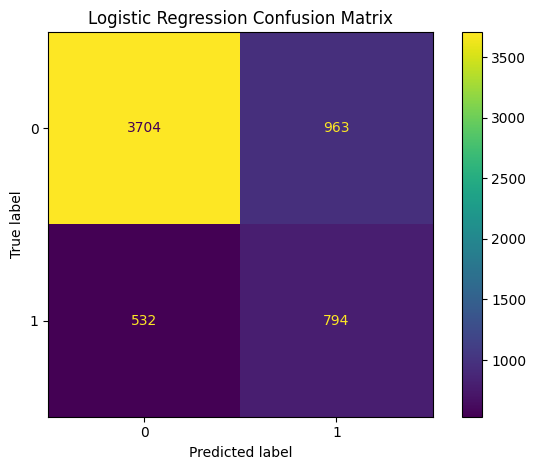

In [49]:
logreg_results = evaluate_classifier(
    "Logistic Regression",
    logreg_model,
    X_test,
    y_test
)